<a href="https://colab.research.google.com/github/Emily6999/Bootcamp-EDA/blob/main/%E2%80%9CEDA_activity_ipynb%E2%80%9D%E7%9A%84%E5%89%AF%E6%9C%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### EDA Case Study

**Introduction**

This case study aims to give an idea of applying EDA in a real business scenario. In this case study, we will develop a basic understanding of risk analytics in banking and financial services and understand how data is used to minimize the risk of losing money while lending to customers.

**Business Understanding**

The loan providing companies find it hard to give loans to the people due to their insufficient or non-existent credit history. Because of that, some consumers use it as their advantage by becoming a defaulter. Suppose we work for a consumer finance company which specializes in lending various types of loans to urban customers. We will have to use EDA to analyze the patterns present in the data. This will ensure that the applicants capable of repaying the loan are not rejected.

When the company receives a loan application, the company has to decide for loan approval based on the applicant’s profile. Two types of risks are associated with the bank’s decision:

If the applicant is likely to repay the loan, then not approving the loan results in a loss of business to the company

If the applicant is not likely to repay the loan, i.e. he/she is likely to default, then approving the loan may lead to a financial loss for the company.

The data given below contains the information about the loan application at the time of applying for the loan. It contains two types of scenarios:

The client with payment difficulties: he/she had late payment more than X days on at least one of the first Y instalments of the loan in our sample,

All other cases: All other cases when the payment is paid on time.

When a client applies for a loan, there are four types of decisions that could be taken by the client/company):

Approved: The Company has approved loan Application

Cancelled: The client cancelled the application sometime during approval. Either the client changed her/his mind about the loan or in some cases due to a higher risk of the client he received worse pricing which he did not want.

Refused: The company had rejected the loan (because the client does not meet their requirements etc.).

Unused offer: Loan has been cancelled by the client but on different stages of the process.

In this case study, we will use EDA to understand how consumer attributes and loan attributes influence the tendency of default.

**Business Objectives**

This case study aims to identify patterns which indicate if a client has difficulty paying their installments which may be used for taking actions such as denying the loan, reducing the amount of loan, lending (to risky applicants) at a higher interest rate, etc. This will ensure that the consumers capable of repaying the loan are not rejected. Identification of such applicants using EDA is the aim of this case study.

In other words, the company wants to understand the driving factors (or driver variables) behind loan default, i.e. the variables which are strong indicators of default. The company can utilize this knowledge for its portfolio and risk assessment.

**Data Understanding**

This dataset has 3 files as explained below:

`application_data.csv` contains all the information of the client at the time of application.
The data is about whether a client has payment difficulties.

`previous_application.csv` contains information about the client’s previous loan data. It contains the data whether the previous application had been Approved, Cancelled, Refused or Unused offer.

`columns_description.xlsx` is data dictionary which describes the meaning of the variables.


I have given a link to the data files in a drive folder [here](https://drive.google.com/drive/folders/1YpPjU4Y12MPrMdWaNDa6rS2MNirh2FG3?usp=sharing).  I suggest unzipping them and putting them in your google drive, and link to them directly using colab and its "mount drive" functionality.

### **STEP 1 upload all files and necessary tools**

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')
base="/content/drive/MyDrive/Colab Notebooks/EDA project/"
application = pd.read_csv(base + "application_data.csv")
previous_application = pd.read_csv(base + "previous_application.csv")
columns_description = pd.read_excel(base + "Copy of columns_description.xlsx")

Mounted at /content/drive


### **STEP 2 understand the datasets**
*   file.columns
*   key columns markdown
*   file.describe()



**[application** **file]**

In [ ]:
#basic info of the application sheet
application.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [ ]:
# application_data = every row represent a person who is currently applyiny for the loan
# core columns:
# TARGET -> whether the applicant defaulted before (1=default / payment difficulty, 0=non-default)

# basic info columns:
# SK_ID_CURR -> unique ID of each current applicant
# CODE_GENDER -> applicant gender
# CNT_CHILDREN -> number of children
# NAME_FAMILY_STATUS -> marital/family status
# NAME_EDUCATION_TYPE -> education level
# NAME_HOUSING_TYPE -> housing condition (own/rent/etc.)

# income, credit amount related columns:
# AMT_INCOME_TOTAL -> reveal each applicant's income condition (total income)
# AMT_CREDIT -> requested loan/credit amount
# AMT_ANNUITY -> loan annuity/payment burden (periodic payment)
# AMT_GOODS_PRICE -> goods price related to the loan

# risk related column:
# EXT_SOURCE_1 / EXT_SOURCE_2 / EXT_SOURCE_3 -> external risk score-like variables

# social relationship related columns:
# DEF_30_CNT_SOCIAL_CIRCLE -> number of defaults observed in social circle (30 days)
# OBS_30_CNT_SOCIAL_CIRCLE -> number of observed cases in social circle (30 days)
# DEF_60_CNT_SOCIAL_CIRCLE / OBS_60_CNT_SOCIAL_CIRCLE -> similar indicators (60 days)

In [ ]:
#statistical summary for numeric columns in application sheet
application.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


**[previous application file]**

In [ ]:
#basic info of the previous-application sheet
previous_application.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY',
       'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY',
       'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY',
       'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE',
       'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE',
       'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE',
       'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE',
       'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY',
       'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION',
       'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION',
       'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL'],
      dtype='object')

In [ ]:
# previous_application = each row is one historical loan application of a customer
# This table provides customer history before the current application

# basic info columns:
# SK_ID_PREV -> unique ID of previous application
# SK_ID_CURR -> current customer ID (used to connect to application_data)

# historical application relating credit amount info columns:
# AMT_APPLICATION -> amount applied for in previous application
# AMT_CREDIT -> credit amount in previous application
# AMT_ANNUITY -> annuity/payment amount in previous application
# AMT_DOWN_PAYMENT -> down payment amount (if applicable)

# historical application status:
# NAME_CONTRACT_STATUS -> Approved / Refused / Canceled / etc.
# NAME_CONTRACT_TYPE -> contract/loan type
# NAME_CASH_LOAN_PURPOSE -> purpose of cash loan

# historical application time:
# WEEKDAY_APPR_PROCESS_START -> weekday of previous application processing
# HOUR_APPR_PROCESS_START -> hour of previous application processing
# DAYS_DECISION -> days relative to current application when previous decision was made


In [ ]:
#statistical summary for numeric columns in previous-application sheet
previous_application.describe()

,SK_ID_PREV,SK_ID_CURR,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,HOUR_APPR_PROCESS_START,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,...,RATE_INTEREST_PRIVILEGED,DAYS_DECISION,SELLERPLACE_AREA,CNT_PAYMENT,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
count,1.670214e+06,1.670214e+06,1.297979e+06,1.670214e+06,1.670213e+06,7.743700e+05,1.284699e+06,1.670214e+06,1.670214e+06,774370.000000,...,5951.000000,1.670214e+06,1.670214e+06,1.297984e+06,997149.000000,997149.000000,997149.000000,997149.000000,997149.000000,997149.000000
mean,1.923089e+06,2.783572e+05,1.595512e+04,1.752339e+05,1.961140e+05,6.697402e+03,2.278473e+05,1.248418e+01,9.964675e-01,0.079637,...,0.773503,-8.806797e+02,3.139511e+02,1.605408e+01,342209.855039,13826.269337,33767.774054,76582.403064,81992.343838,0.332570
std,5.325980e+05,1.028148e+05,1.478214e+04,2.927798e+05,3.185746e+05,2.092150e+04,3.153966e+05,3.334028e+00,5.932963e-02,0.107823,...,0.100879,7.790997e+02,7.127443e+03,1.456729e+01,88916.115834,72444.869708,106857.034789,149647.415123,153303.516729,0.471134
min,1.000001e+06,1.000010e+05,0.000000e+00,0.000000e+00,0.000000e+00,-9.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,-0.000015,...,0.373150,-2.922000e+03,-1.000000e+00,0.000000e+00,-2922.000000,-2892.000000,-2801.000000,-2889.000000,-2874.000000,0.000000
25%,1.461857e+06,1.893290e+05,6.321780e+03,1.872000e+04,2.416050e+04,0.000000e+00,5.084100e+04,1.000000e+01,1.000000e+00,0.000000,...,0.715645,-1.300000e+03,-1.000000e+00,6.000000e+00,365243.000000,-1628.000000,-1242.000000,-1314.000000,-1270.000000,0.000000
50%,1.923110e+06,2.787145e+05,1.125000e+04,7.104600e+04,8.054100e+04,1.638000e+03,1.123200e+05,1.200000e+01,1.000000e+00,0.051605,...,0.835095,-5.810000e+02,3.000000e+00,1.200000e+01,365243.000000,-831.000000,-361.000000,-537.000000,-499.000000,0.000000
75%,2.384280e+06,3.675140e+05,2.065842e+04,1.803600e+05,2.164185e+05,7.740000e+03,2.340000e+05,1.500000e+01,1.000000e+00,0.108909,...,0.852537,-2.800000e+02,8.200000e+01,2.400000e+01,365243.000000,-411.000000,129.000000,-74.000000,-44.000000,1.000000
max,2.845382e+06,4.562550e+05,4.180581e+05,6.905160e+06,6.905160e+06,3.060045e+06,6.905160e+06,2.300000e+01,1.000000e+00,1.000000,...,1.000000,-1.000000e+00,4.000000e+06,8.400000e+01,365243.000000,365243.000000,365243.000000,365243.000000,365243.000000,1.000000


### **STEP 3 Analyze the Relationship Between Individual Factors and Default Rate**

**3.1 Education level vs default rate**

,NAME_EDUCATION_TYPE,customers,default_rate
3,Lower secondary,3816,10.927673
4,Secondary / secondary special,218391,8.939929
2,Incomplete higher,10277,8.484966
1,Higher education,74863,5.355115
0,Academic degree,164,1.829268


Text(0.5, 0, 'Education Type')

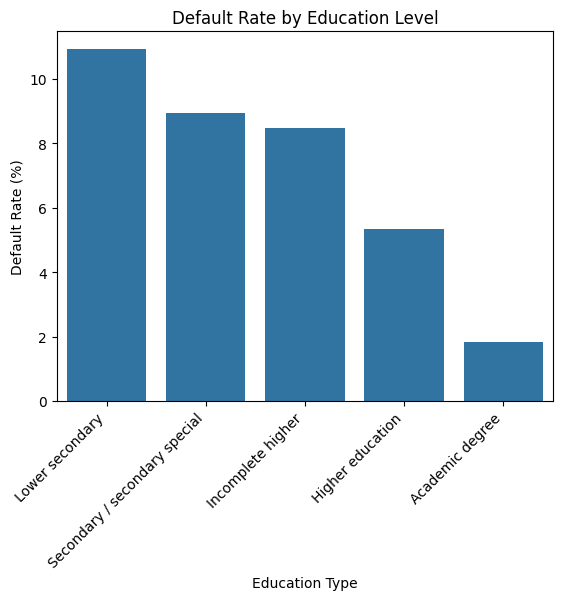

In [ ]:
# Groups with lower education level may show a higher default rate, which suggests education level is related to repayment stability.
edu_default = application.groupby("NAME_EDUCATION_TYPE")["TARGET"].agg(["count", "mean"]).reset_index()
edu_default = edu_default.rename(columns={"count": "customers", "mean": "default_rate"})
edu_default["default_rate"] = edu_default["default_rate"] * 100
edu_default = edu_default.sort_values("default_rate", ascending=False)

display(edu_default)

sns.barplot(data=edu_default, x="NAME_EDUCATION_TYPE", y="default_rate")
plt.xticks(rotation=45, ha="right")
plt.title("Default Rate by Education Level")
plt.ylabel("Default Rate (%)")
plt.xlabel("Education Type")

**3.2 Income type vs default rate**

,NAME_INCOME_TYPE,customers,default_rate
2,Maternity leave,5,40.000000
6,Unemployed,22,36.363636
7,Working,158774,9.588472
1,Commercial associate,71617,7.484257
4,State servant,21703,5.754965
3,Pensioner,55362,5.386366
0,Businessman,10,0.000000
5,Student,18,0.000000


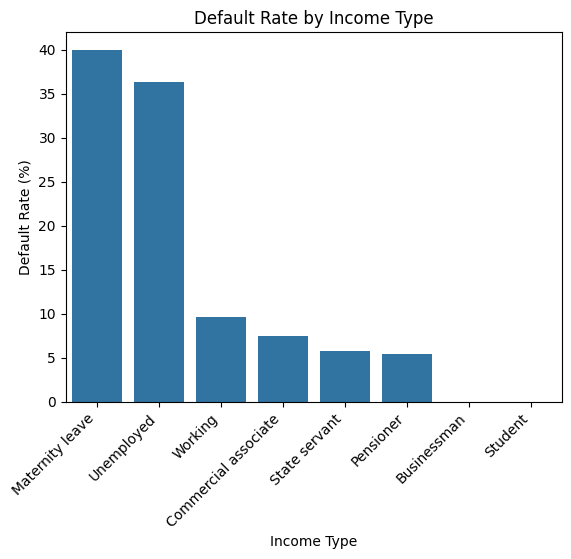

In [ ]:
# (2)income type
# Different income sources may have different repayment risk profiles.
income_type_default = application.groupby("NAME_INCOME_TYPE")["TARGET"].agg(["count", "mean"]).reset_index()
income_type_default = income_type_default.rename(columns={"count": "customers", "mean": "default_rate"})
income_type_default["default_rate"] = income_type_default["default_rate"] * 100
income_type_default = income_type_default.sort_values("default_rate", ascending=False)

display(income_type_default)

sns.barplot(data=income_type_default, x="NAME_INCOME_TYPE", y="default_rate")
plt.xticks(rotation=45, ha="right")
plt.title("Default Rate by Income Type")
plt.ylabel("Default Rate (%)")
plt.xlabel("Income Type")
plt.show()

Text(0.5, 0, 'Default Rate')

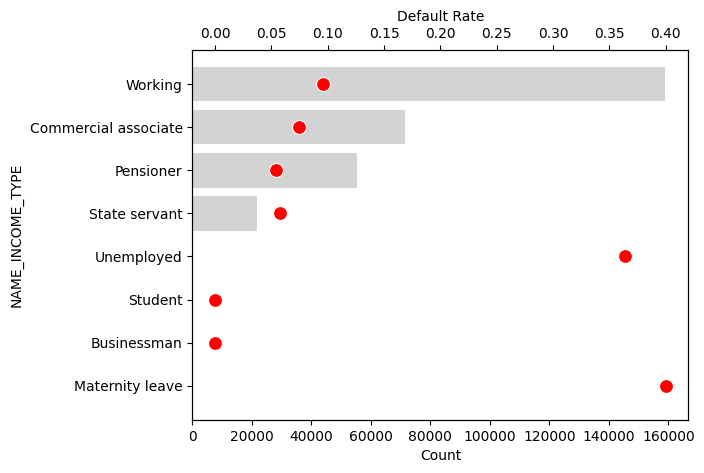

In [ ]:
# another way
income_stats = (
    application
    .groupby('NAME_INCOME_TYPE')['TARGET']
    .agg(['count', 'mean'])
    .reset_index()
)

income_stats = income_stats.sort_values('count', ascending=False)
fig, ax1 = plt.subplots()
sns.barplot(
    data=income_stats,
    x='count',
    y='NAME_INCOME_TYPE',
    color='lightgray',
    ax=ax1
)
ax1.set_xlabel('Count')
ax2 = ax1.twiny()
sns.scatterplot(
    data=income_stats,
    x='mean',
    y='NAME_INCOME_TYPE',
    color='red',
    s=100,
    ax=ax2
)
ax2.set_xlabel('Default Rate')

**3.3 Occupation type vs default rate**

,OCCUPATION_TYPE,customers,default_rate
9,Low-skill Laborers,2093,17.152413
4,Drivers,18603,11.326130
17,Waiters/barmen staff,1348,11.275964
16,Security staff,6721,10.742449
8,Laborers,55186,10.578770
2,Cooking staff,5946,10.443996
14,Sales staff,32102,9.631799
1,Cleaning staff,4653,9.606705
15,Secretaries,1305,7.049808
11,Medicine staff,8537,6.700246


/tmp/ipykernel_181/4032952274.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Low-skill Laborers'),
  Text(1, 0, 'Drivers'),
  Text(2, 0, 'Waiters/barmen staff'),
  Text(3, 0, 'Security staff'),
  Text(4, 0, 'Laborers'),
  Text(5, 0, 'Cooking staff'),
  Text(6, 0, 'Sales staff'),
  Text(7, 0, 'Cleaning staff'),
  Text(8, 0, 'Secretaries'),
  Text(9, 0, 'Medicine staff'),
  Text(10, 0, 'Private service staff'),
  Text(11, 0, 'Core staff'),
  Text(12, 0, 'Managers'),
  Text(13, 0, 'High skill tech staff'),
  Text(14, 0, 'Accountants')])

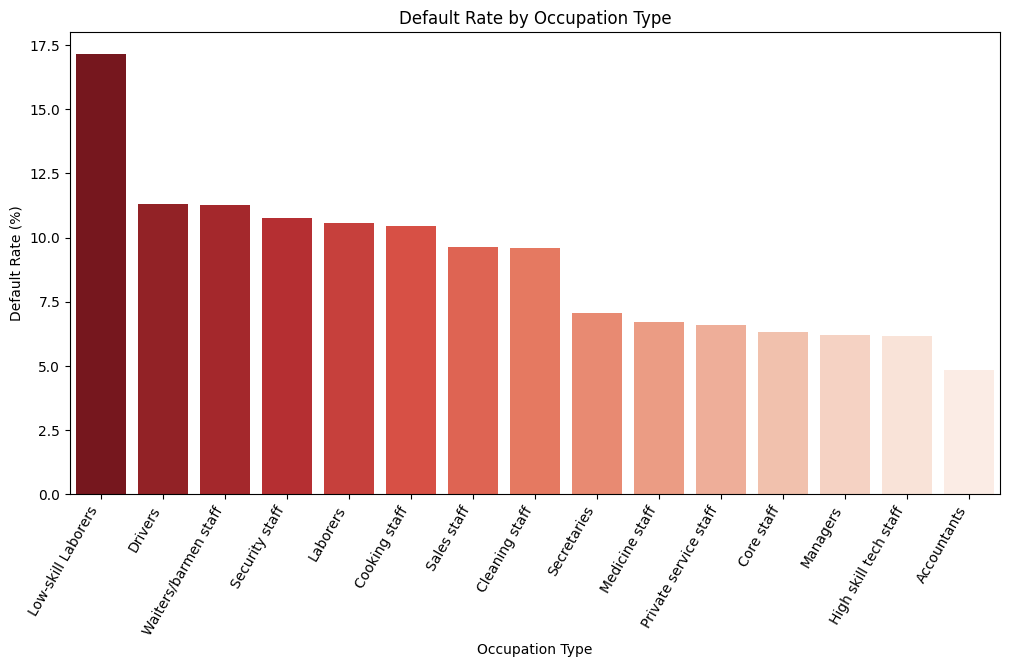

In [ ]:
occ_tmp = application[["OCCUPATION_TYPE", "TARGET"]].dropna().copy()
occ_default = (
    occ_tmp.groupby("OCCUPATION_TYPE")["TARGET"]
    .agg(["count", "mean"])
    .reset_index()
)

occ_default = occ_default.rename(
    columns={"count": "customers", "mean": "default_rate"}
)

occ_default["default_rate"] = occ_default["default_rate"] * 100
occ_default = occ_default[occ_default["customers"] > 1000]
occ_default = occ_default.sort_values("default_rate", ascending=False)
display(occ_default)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=occ_default,
    x="OCCUPATION_TYPE",
    y="default_rate",
    palette="Reds_r"
)

plt.title("Default Rate by Occupation Type")
plt.xlabel("Occupation Type")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=60, ha="right")


**3.4 Housing type vs default rate**

,NAME_HOUSING_TYPE,customers,default_rate
4,Rented apartment,4881,12.313051
5,With parents,14840,11.698113
2,Municipal apartment,11183,8.539748
0,Co-op apartment,1122,7.932264
1,House / apartment,272868,7.795711
3,Office apartment,2617,6.572411


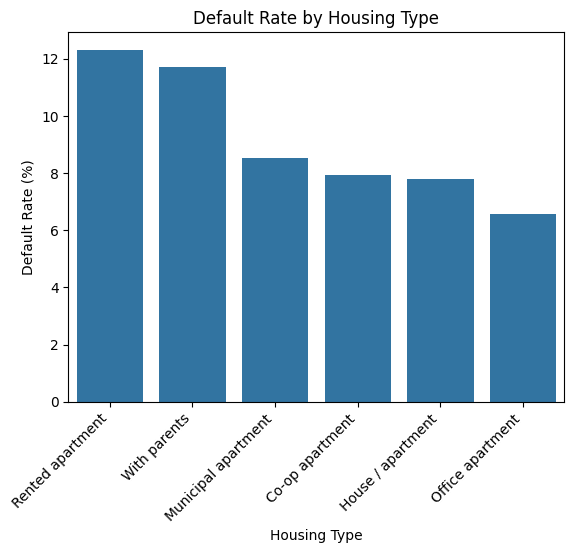

In [ ]:
housing_default = application.groupby("NAME_HOUSING_TYPE")["TARGET"].agg(["count", "mean"]).reset_index()
housing_default = housing_default.rename(columns={"count": "customers", "mean": "default_rate"})
housing_default["default_rate"] = housing_default["default_rate"] * 100
housing_default = housing_default.sort_values("default_rate", ascending=False)

display(housing_default)

sns.barplot(data=housing_default, x="NAME_HOUSING_TYPE", y="default_rate")
plt.xticks(rotation=45, ha="right")
plt.title("Default Rate by Housing Type")
plt.ylabel("Default Rate (%)")
plt.xlabel("Housing Type")
plt.show()

**3.5 Family status vs default rate**

,NAME_FAMILY_STATUS,customers,default_rate
0,Civil marriage,29775,9.944584
3,Single / not married,45444,9.807675
2,Separated,19770,8.194234
1,Married,196432,7.559868
5,Widow,16088,5.824217
4,Unknown,2,0.000000


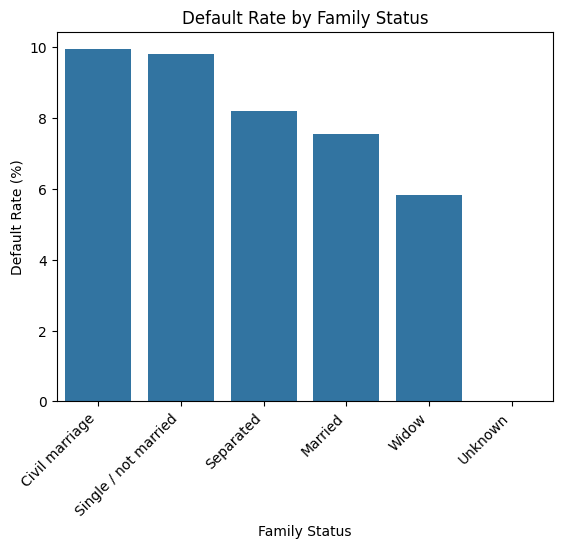

In [ ]:
family_default = application.groupby("NAME_FAMILY_STATUS")["TARGET"].agg(["count", "mean"]).reset_index()
family_default = family_default.rename(columns={"count": "customers", "mean": "default_rate"})
family_default["default_rate"] = family_default["default_rate"] * 100
family_default = family_default.sort_values("default_rate", ascending=False)

display(family_default)

sns.barplot(data=family_default, x="NAME_FAMILY_STATUS", y="default_rate")
plt.xticks(rotation=45, ha="right")
plt.title("Default Rate by Family Status")
plt.ylabel("Default Rate (%)")
plt.xlabel("Family Status")
plt.show()

,NAME_FAMILY_STATUS,customers,default_rate
0,Civil marriage,29775,9.944584
3,Single / not married,45444,9.807675
2,Separated,19770,8.194234
1,Married,196432,7.559868
5,Widow,16088,5.824217
4,Unknown,2,0.000000


/tmp/ipykernel_181/800370666.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Civil marriage'),
  Text(1, 0, 'Single / not married'),
  Text(2, 0, 'Separated'),
  Text(3, 0, 'Married'),
  Text(4, 0, 'Widow'),
  Text(5, 0, 'Unknown')])

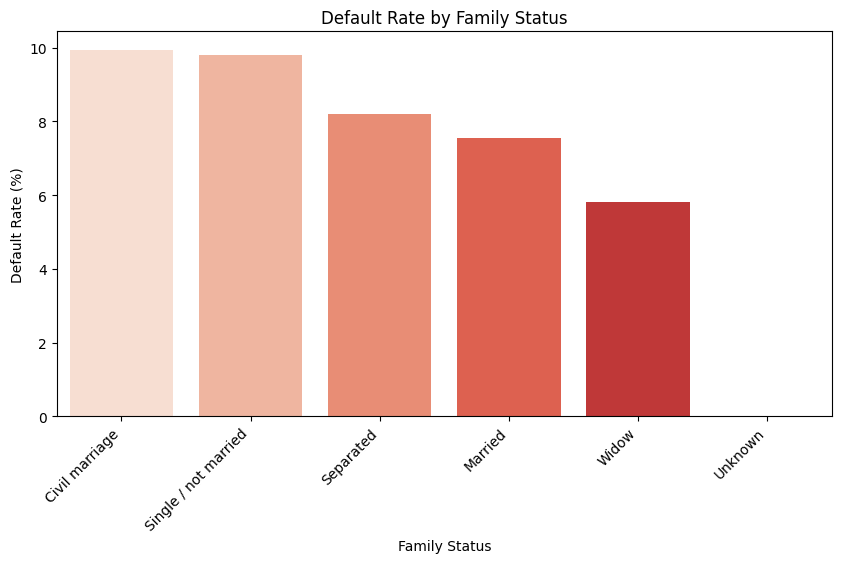

In [ ]:
# another graph
family_tmp = application[["NAME_FAMILY_STATUS", "TARGET"]].dropna().copy()
family_default = (
    family_tmp.groupby("NAME_FAMILY_STATUS")["TARGET"]
    .agg(["count", "mean"])
    .reset_index()
)

family_default = family_default.rename(
    columns={"count": "customers", "mean": "default_rate"}
)
family_default["default_rate"] = family_default["default_rate"] * 100
family_default = family_default.sort_values("default_rate", ascending=False)

display(family_default)


plt.figure(figsize=(10, 5))
sns.barplot(
    data=family_default,
    x="NAME_FAMILY_STATUS",
    y="default_rate",
    palette="Reds"
)

plt.title("Default Rate by Family Status")
plt.xlabel("Family Status")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45, ha="right")


**3.6 Car ownership vs default rate**

,FLAG_OWN_CAR,customers,default_rate
0,N,202924,8.500227
1,Y,104587,7.243730


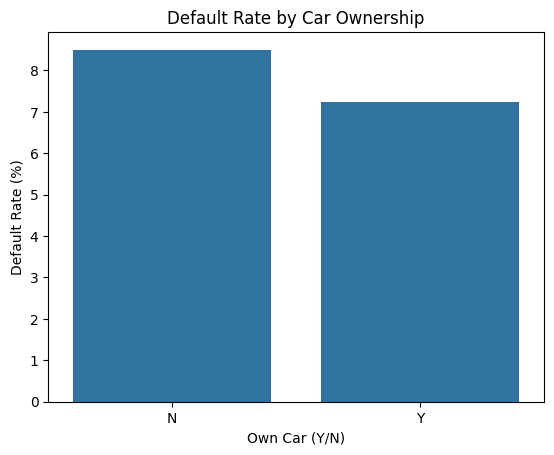

In [ ]:
car_default = application.groupby("FLAG_OWN_CAR")["TARGET"].agg(["count", "mean"]).reset_index()
car_default = car_default.rename(columns={"count": "customers", "mean": "default_rate"})
car_default["default_rate"] = car_default["default_rate"] * 100
car_default = car_default.sort_values("default_rate", ascending=False)

display(car_default)

sns.barplot(data=car_default, x="FLAG_OWN_CAR", y="default_rate")
plt.title("Default Rate by Car Ownership")
plt.ylabel("Default Rate (%)")
plt.xlabel("Own Car (Y/N)")
plt.show()

**3.7 Realty ownership vs default rate**

,FLAG_OWN_REALTY,customers,default_rate
0,N,94199,8.324929
1,Y,213312,7.961577


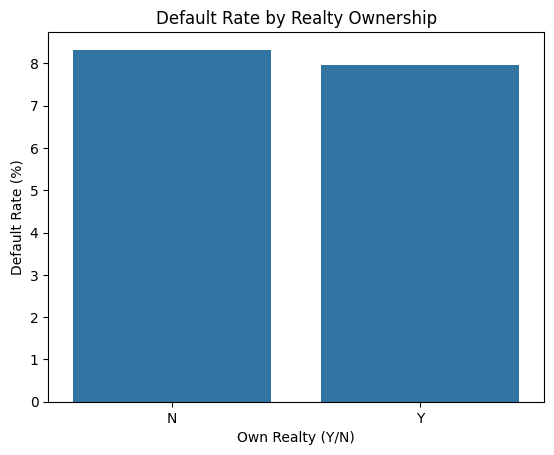

In [ ]:
realty_default = application.groupby("FLAG_OWN_REALTY")["TARGET"].agg(["count", "mean"]).reset_index()
realty_default = realty_default.rename(columns={"count": "customers", "mean": "default_rate"})
realty_default["default_rate"] = realty_default["default_rate"] * 100
realty_default = realty_default.sort_values("default_rate", ascending=False)

display(realty_default)

sns.barplot(data=realty_default, x="FLAG_OWN_REALTY", y="default_rate")
plt.title("Default Rate by Realty Ownership")
plt.ylabel("Default Rate (%)")
plt.xlabel("Own Realty (Y/N)")
plt.show()

**3.8 Credit amount vs default rate**

/tmp/ipykernel_181/475538689.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  credit_default = credit_tmp.groupby("CREDIT_BIN")["TARGET"].agg(["count", "mean"]).reset_index()


,CREDIT_BIN,customers,default_rate
0,"(44999.999, 180000.0]",33204,6.722082
1,"(180000.0, 254700.0]",31721,7.777182
2,"(254700.0, 306306.0]",27391,8.207075
3,"(306306.0, 432000.0]",30707,10.033543
4,"(432000.0, 513531.0]",30826,9.589308
5,"(513531.0, 604152.0]",30726,10.522033
6,"(604152.0, 755190.0]",34066,8.536371
7,"(755190.0, 900000.0]",29958,7.079912
8,"(900000.0, 1133748.0]",28319,6.882305
9,"(1133748.0, 4050000.0]",30593,5.328016


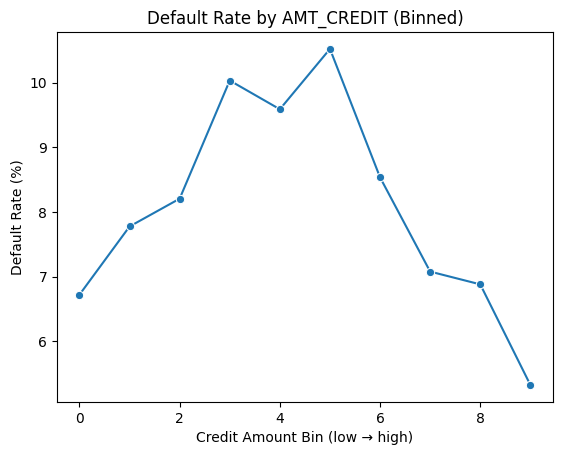

In [ ]:
credit_tmp = application[["AMT_CREDIT", "TARGET"]].dropna().copy()
credit_tmp["CREDIT_BIN"] = pd.qcut(credit_tmp["AMT_CREDIT"], q=10, duplicates="drop")

credit_default = credit_tmp.groupby("CREDIT_BIN")["TARGET"].agg(["count", "mean"]).reset_index()
credit_default = credit_default.rename(columns={"count": "customers", "mean": "default_rate"})
credit_default["default_rate"] = credit_default["default_rate"] * 100

display(credit_default)

sns.lineplot(data=credit_default, x=credit_default.index, y="default_rate", marker="o")
plt.title("Default Rate by AMT_CREDIT (Binned)")
plt.ylabel("Default Rate (%)")
plt.xlabel("Credit Amount Bin (low → high)")
plt.show()

,NAME_CONTRACT_TYPE,customers,default_rate
0,Cash loans,278232,8.345913
1,Revolving loans,29279,5.478329


/tmp/ipykernel_181/3657714940.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


([0, 1], [Text(0, 0, 'Cash loans'), Text(1, 0, 'Revolving loans')])

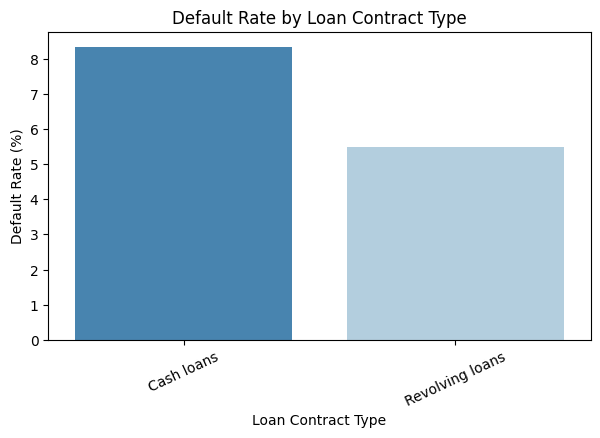

In [ ]:
contract_tmp = application[["NAME_CONTRACT_TYPE", "TARGET"]].dropna().copy()
contract_default = (
    contract_tmp.groupby("NAME_CONTRACT_TYPE")["TARGET"]
    .agg(["count", "mean"])
    .reset_index()
)
contract_default = contract_default.rename(
    columns={"count": "customers", "mean": "default_rate"}
)
contract_default["default_rate"] = contract_default["default_rate"] * 100
display(contract_default)

plt.figure(figsize=(7, 4))
sns.barplot(
    data=contract_default,
    x="NAME_CONTRACT_TYPE",
    y="default_rate",
    palette="Blues_r"
)

plt.title("Default Rate by Loan Contract Type")
plt.xlabel("Loan Contract Type")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=25)

**3.9 Income amount vs default rate**

/tmp/ipykernel_181/3571384221.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_default_num = income_tmp.groupby("INCOME_BIN")["TARGET"].agg(["count", "mean"]).reset_index()


,INCOME_BIN,customers,default_rate
0,"(25649.999, 81000.0]",33391,8.190830
1,"(81000.0, 99000.0]",30280,8.223250
2,"(99000.0, 112500.0]",36907,8.719213
3,"(112500.0, 135000.0]",48849,8.489427
4,"(135000.0, 147150.0]",4333,9.000692
5,"(147150.0, 162000.0]",31120,8.640746
6,"(162000.0, 180000.0]",30704,8.422355
7,"(180000.0, 225000.0]",44809,7.806467
8,"(225000.0, 270000.0]",19957,7.040136
9,"(270000.0, 117000000.0]",27161,6.137477


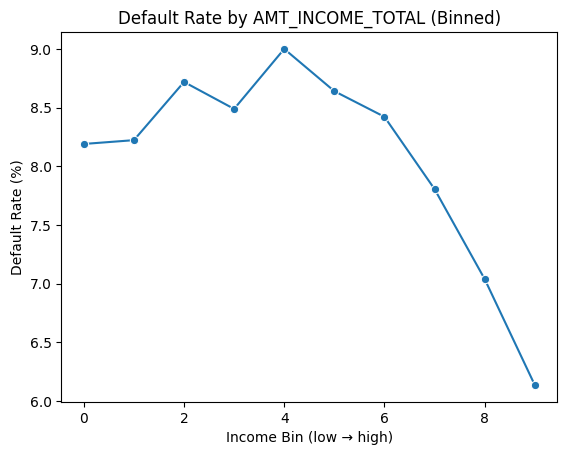

In [ ]:
income_tmp = application[["AMT_INCOME_TOTAL", "TARGET"]].dropna().copy()
income_tmp["INCOME_BIN"] = pd.qcut(income_tmp["AMT_INCOME_TOTAL"], q=10, duplicates="drop")

income_default_num = income_tmp.groupby("INCOME_BIN")["TARGET"].agg(["count", "mean"]).reset_index()
income_default_num = income_default_num.rename(columns={"count": "customers", "mean": "default_rate"})
income_default_num["default_rate"] = income_default_num["default_rate"] * 100

display(income_default_num)

sns.lineplot(data=income_default_num, x=income_default_num.index, y="default_rate", marker="o")
plt.title("Default Rate by AMT_INCOME_TOTAL (Binned)")
plt.ylabel("Default Rate (%)")
plt.xlabel("Income Bin (low → high)")
plt.show()

**3.10 previous application status vs default rate**

/tmp/ipykernel_181/1653085418.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  refused_default = refused_tmp.groupby("REFUSED_BIN")["TARGET"].agg(["count", "mean"]).reset_index()


,REFUSED_BIN,customers,default_rate
0,"(-0.001, 2.0]",276490,7.563384
1,"(2.0, 68.0]",31021,12.614036


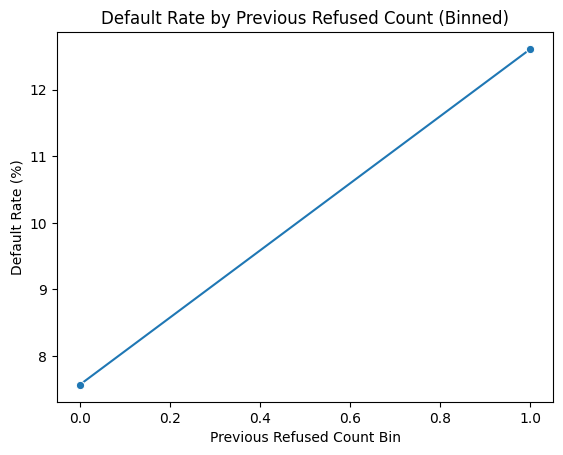

In [ ]:
refused_only = previous_application[previous_application["NAME_CONTRACT_STATUS"] == "Refused"]

refused_count = refused_only.groupby("SK_ID_CURR").size().reset_index(name="PREV_REFUSED_COUNT")

app_prev = application.merge(refused_count, on="SK_ID_CURR", how="left")
app_prev["PREV_REFUSED_COUNT"] = app_prev["PREV_REFUSED_COUNT"].fillna(0)
refused_tmp = app_prev[["PREV_REFUSED_COUNT", "TARGET"]].dropna().copy()
refused_tmp["REFUSED_BIN"] = pd.qcut(refused_tmp["PREV_REFUSED_COUNT"], q=6, duplicates="drop")

refused_default = refused_tmp.groupby("REFUSED_BIN")["TARGET"].agg(["count", "mean"]).reset_index()
refused_default = refused_default.rename(columns={"count": "customers", "mean": "default_rate"})
refused_default["default_rate"] = refused_default["default_rate"] * 100

display(refused_default)

sns.lineplot(data=refused_default, x=refused_default.index, y="default_rate", marker="o")
plt.title("Default Rate by Previous Refused Count (Binned)")
plt.ylabel("Default Rate (%)")
plt.xlabel("Previous Refused Count Bin")
plt.show()

**3.11 Age distribution analysis**

/tmp/ipykernel_181/2361494662.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_default_rate = age_rate_df.groupby("AGE_BIN")["TARGET"].agg(["count", "mean"]).reset_index()


,AGE_BIN,customers,default_rate
0,"(20.517, 28.175]",30752,11.569979
1,"(28.175, 32.038]",30760,10.994798
2,"(32.038, 36.0]",30745,9.806473
3,"(36.0, 39.496]",30759,8.852694
4,"(39.496, 43.151]",30745,7.903724
5,"(43.151, 47.178]",30764,7.794825
6,"(47.178, 51.74]",30733,7.135652
7,"(51.74, 56.093]",30758,6.343065
8,"(56.093, 60.77]",30757,5.423156
9,"(60.77, 69.121]",30738,4.902726


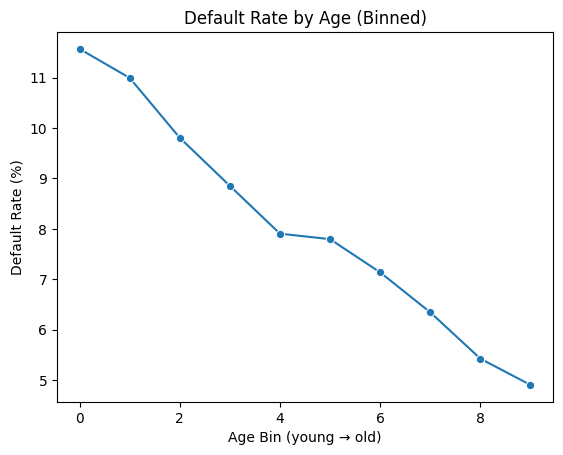

In [ ]:
age_rate_df = application[["TARGET", "DAYS_BIRTH"]].dropna().copy()
age_rate_df["AGE_YEARS"] = -age_rate_df["DAYS_BIRTH"] / 365

age_rate_df["AGE_BIN"] = pd.qcut(age_rate_df["AGE_YEARS"], q=10, duplicates="drop")

age_default_rate = age_rate_df.groupby("AGE_BIN")["TARGET"].agg(["count", "mean"]).reset_index()
age_default_rate = age_default_rate.rename(columns={"count": "customers", "mean": "default_rate"})
age_default_rate["default_rate"] = age_default_rate["default_rate"] * 100

display(age_default_rate)

sns.lineplot(data=age_default_rate, x=age_default_rate.index, y="default_rate", marker="o")
plt.title("Default Rate by Age (Binned)")
plt.xlabel("Age Bin (young → old)")
plt.ylabel("Default Rate (%)")
plt.show()

**3.12 External score vs default rate**

Text(0.5, 1.0, 'Distribution of EXT_SOURCE_3 by TARGET')

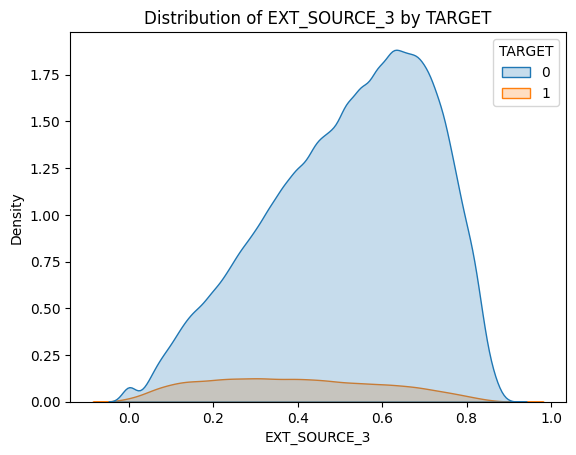

In [ ]:
# EXT_SOURCE_3 (Credit Score Analysis)
sns.kdeplot(data=application, x='EXT_SOURCE_3', hue='TARGET', fill=True)
plt.title("Distribution of EXT_SOURCE_3 by TARGET")

### **PART 4 Distribution Comparison of Default and No Default**
Because non-default applicants are the majority in the dataset, in addition to default-rate analysis, we also try to compare the distribution of Default and No Default groups across different factors which helps us better understand the sample structure and group composition under each condition.

**4.1 Compare Default vs No Default by Loan Contract Type**

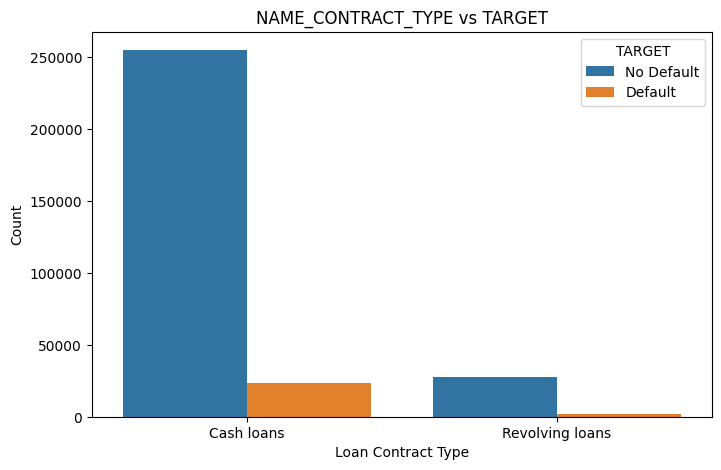

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=application, x="NAME_CONTRACT_TYPE", hue="TARGET")

plt.title("NAME_CONTRACT_TYPE vs TARGET")
plt.xlabel("Loan Contract Type")
plt.ylabel("Count")
plt.legend(title="TARGET", labels=["No Default", "Default"])
plt.show()

**4.2 Compare Default vs No Default by Gender**

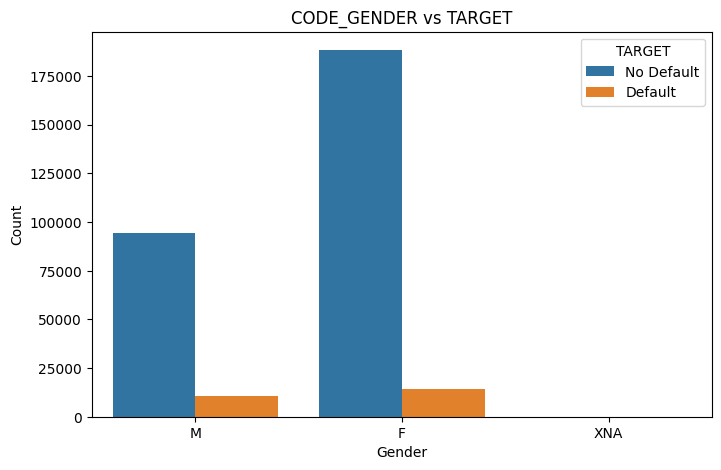

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=application, x="CODE_GENDER", hue="TARGET")

plt.title("CODE_GENDER vs TARGET")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="TARGET", labels=["No Default", "Default"])
plt.show()

**4.3 Compare Default vs No Default by Car Ownership**

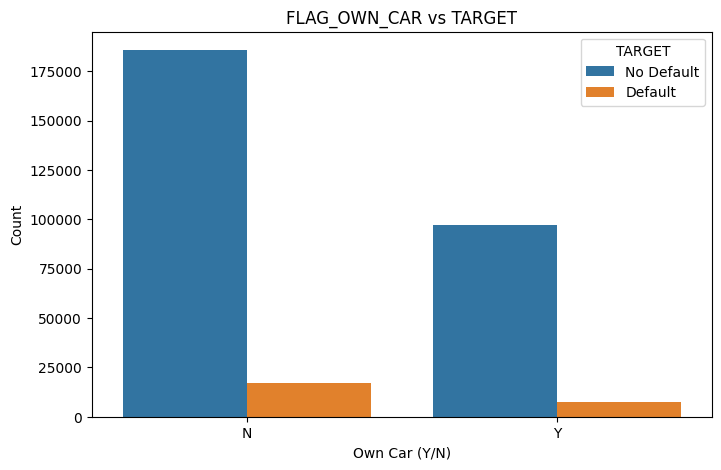

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=application, x="FLAG_OWN_CAR", hue="TARGET")

plt.title("FLAG_OWN_CAR vs TARGET")
plt.xlabel("Own Car (Y/N)")
plt.ylabel("Count")
plt.legend(title="TARGET", labels=["No Default", "Default"])
plt.show()

**4.4 Compare Default vs No Default by Realty Ownership**

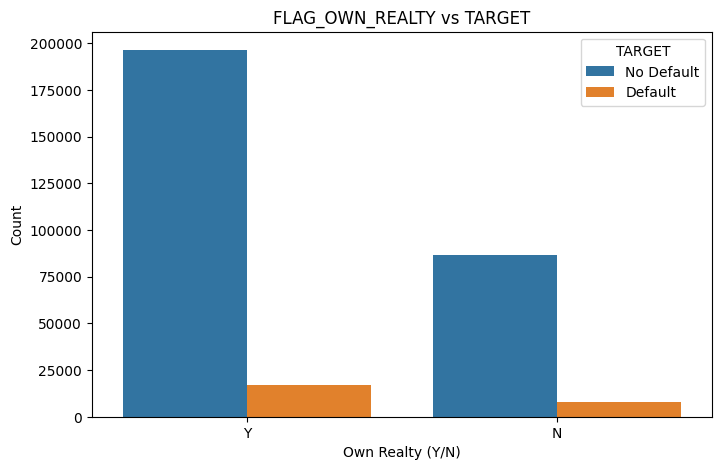

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=application, x="FLAG_OWN_REALTY", hue="TARGET")

plt.title("FLAG_OWN_REALTY vs TARGET")
plt.xlabel("Own Realty (Y/N)")
plt.ylabel("Count")
plt.legend(title="TARGET", labels=["No Default", "Default"])
plt.show()

**4.5 Compare Default vs No Default by Education Type**

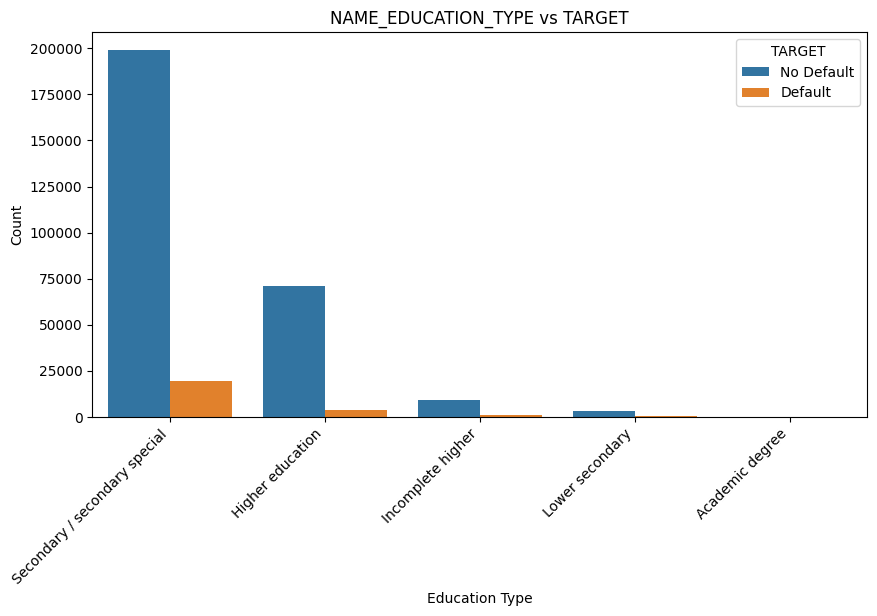

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=application, x="NAME_EDUCATION_TYPE", hue="TARGET")

plt.title("NAME_EDUCATION_TYPE vs TARGET")
plt.xlabel("Education Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="TARGET", labels=["No Default", "Default"])
plt.show()

**4.6 Compare Default vs No Default by Income Type**

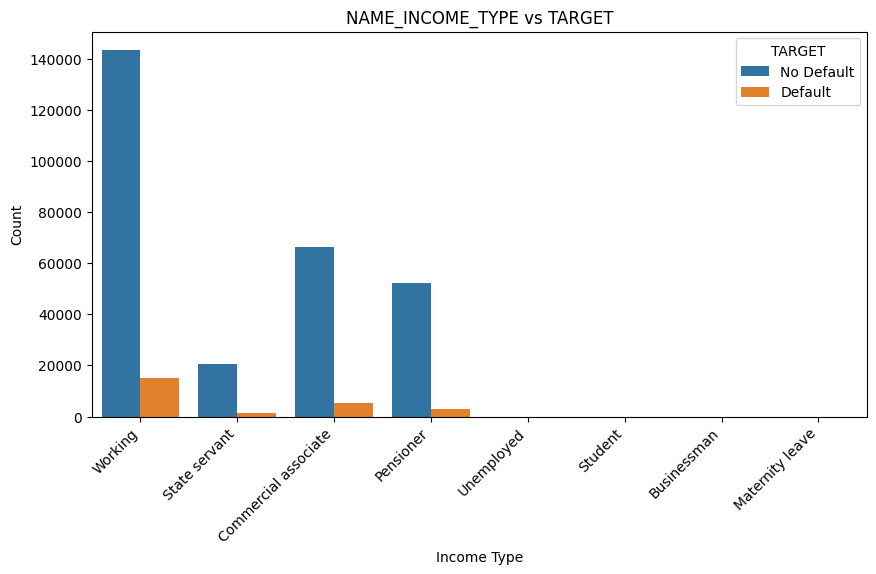

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=application, x="NAME_INCOME_TYPE", hue="TARGET")

plt.title("NAME_INCOME_TYPE vs TARGET")
plt.xlabel("Income Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="TARGET", labels=["No Default", "Default"])
plt.show()

**4.7 Compare Default vs No Default by Family Status**

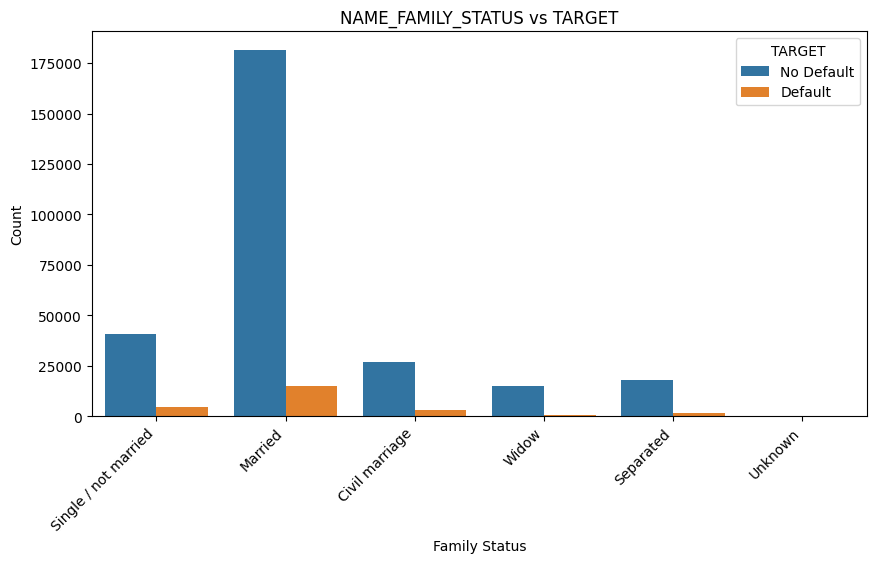

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=application, x="NAME_FAMILY_STATUS", hue="TARGET")

plt.title("NAME_FAMILY_STATUS vs TARGET")
plt.xlabel("Family Status")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="TARGET", labels=["No Default", "Default"])
plt.show()

**4.8 Compare Default vs No Default by Housing Type**

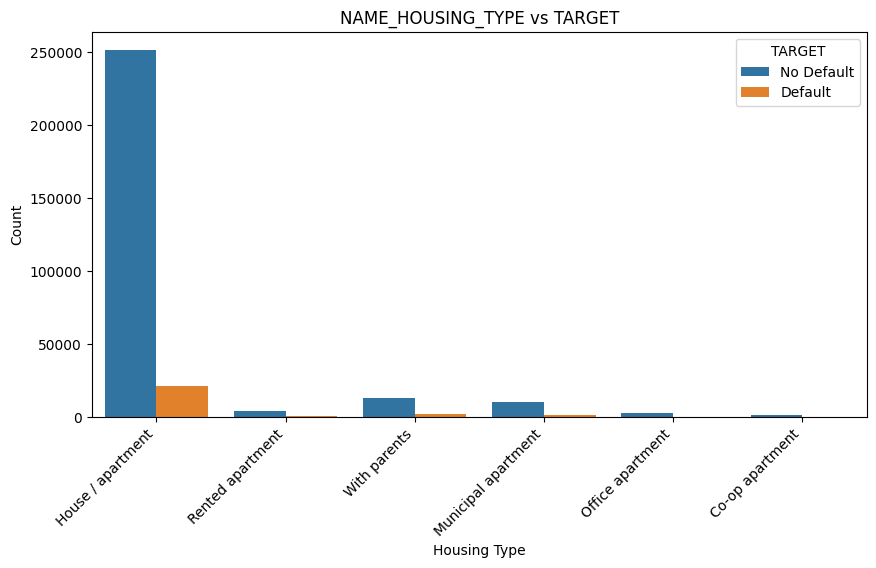

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=application, x="NAME_HOUSING_TYPE", hue="TARGET")

plt.title("NAME_HOUSING_TYPE vs TARGET")
plt.xlabel("Housing Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="TARGET", labels=["No Default", "Default"])
plt.show()

**4.9 Compare Default vs No Default by Occupation Type**

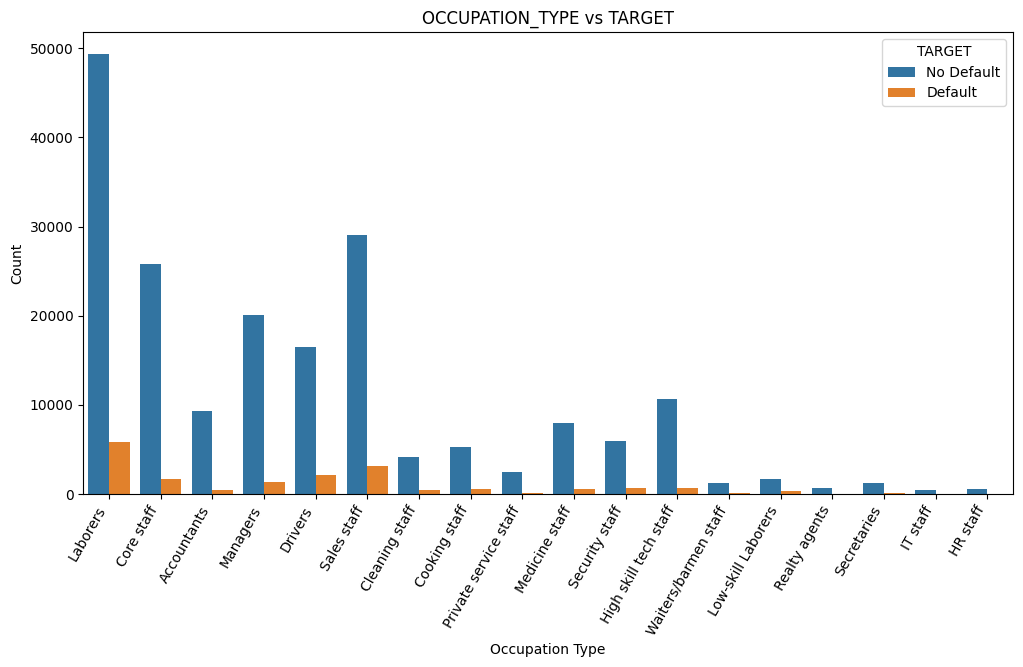

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=application, x="OCCUPATION_TYPE", hue="TARGET")

plt.title("OCCUPATION_TYPE vs TARGET")
plt.xlabel("Occupation Type")
plt.ylabel("Count")
plt.xticks(rotation=60, ha="right")
plt.legend(title="TARGET", labels=["No Default", "Default"])
plt.show()

**4.10 Compare Age Distrib**

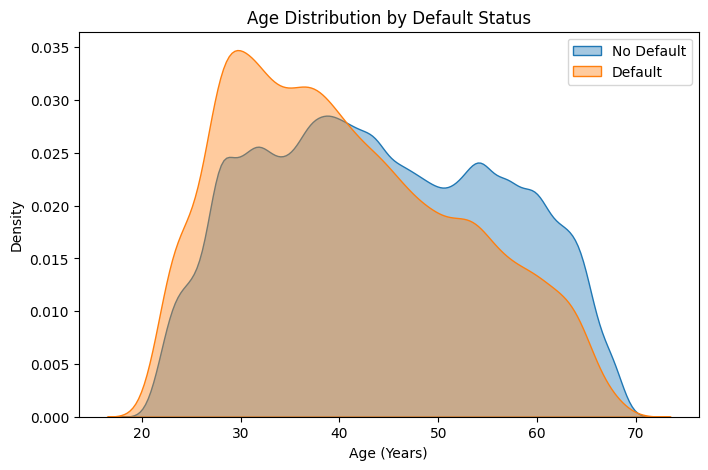

In [ ]:
age_compare = application[["TARGET", "DAYS_BIRTH"]].dropna().copy()
age_compare["AGE_YEARS"] = -age_compare["DAYS_BIRTH"] / 365

plt.figure(figsize=(8, 5))
sns.kdeplot(data=age_compare[age_compare["TARGET"] == 0], x="AGE_YEARS", label="No Default", fill=True, alpha=0.4)
sns.kdeplot(data=age_compare[age_compare["TARGET"] == 1], x="AGE_YEARS", label="Default", fill=True, alpha=0.4)

plt.title("Age Distribution by Default Status")
plt.xlabel("Age (Years)")
plt.ylabel("Density")
plt.legend()
plt.show()

### **STEP 5 Correlation Analysis**

In [ ]:
corr_cols = [
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "DEF_60_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE"
]

available_corr_cols = [c for c in corr_cols if c in application.columns]

corr_df = application[available_corr_cols].copy()
corr_matrix = corr_df.corr()
plt.show()

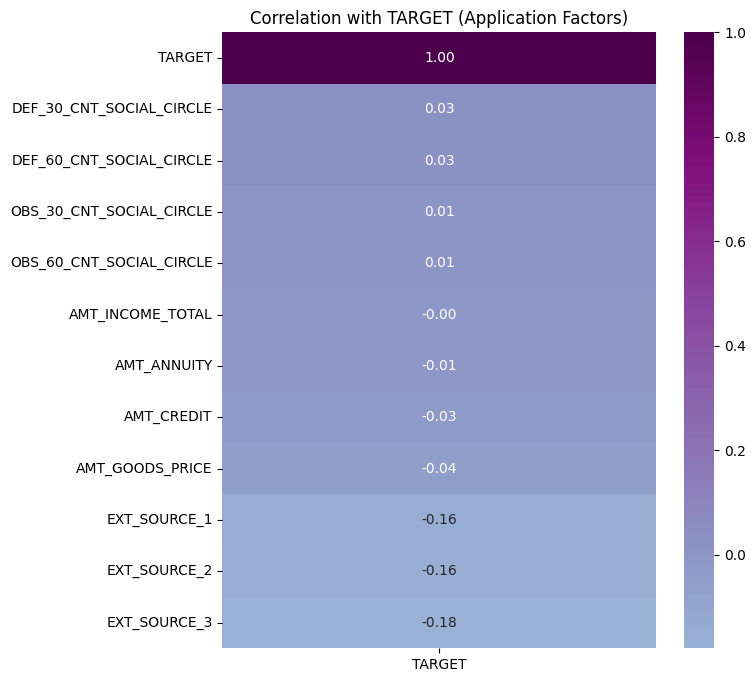

In [ ]:
app_target_corr = corr_matrix[["TARGET"]].sort_values("TARGET", ascending=False)

plt.figure(figsize=(7, 8))
sns.heatmap(app_target_corr, annot=True, cmap="BuPu", center=0, fmt=".2f")
plt.title("Correlation with TARGET (Application Factors)")
plt.show()

/tmp/ipykernel_181/2903716113.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_age_ext2 = application.pivot_table(values='TARGET',index='age_bin',columns='ext2_bin',aggfunc='mean')


<Axes: xlabel='ext2_bin', ylabel='age_bin'>

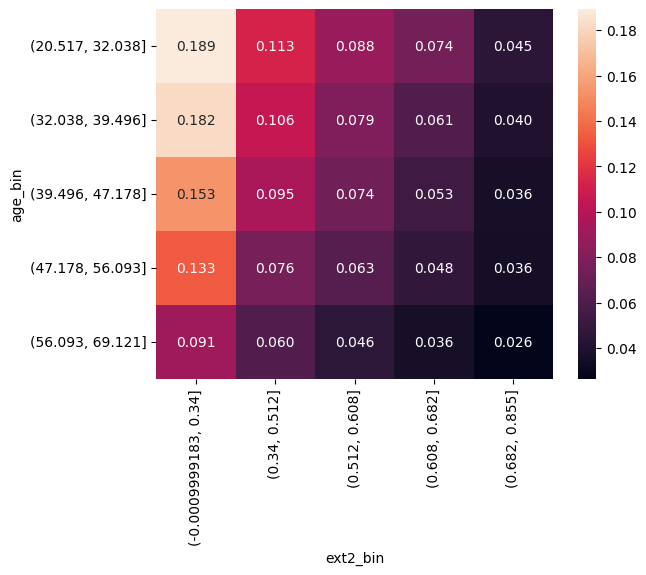

In [ ]:
#Interaction Effect: Age × External Risk Score
application['AGE'] = -application['DAYS_BIRTH'] / 365
application['age_bin'] = pd.qcut(application['AGE'],5,duplicates='drop')
application['ext2_bin'] = pd.qcut(application['EXT_SOURCE_2'],5,duplicates='drop')

pivot_age_ext2 = application.pivot_table(values='TARGET',index='age_bin',columns='ext2_bin',aggfunc='mean')
sns.heatmap(pivot_age_ext2, annot=True, fmt=".3f")

### **STEP 6 Historical Behavior Supplement Using**

application_data is the current application-level table (one row per current applicant)

while previous_application is a historical application-level table (multiple rows per customer possible)

The two tables are linked by SK_ID_CURR, which allows us to connect current default outcomes with past application behavior.

In [ ]:
# Count how many previous applications each current customer has
prev_app_count = previous_application.groupby("SK_ID_CURR").size().reset_index(name="PREV_APP_COUNT")

display(prev_app_count.head())

,SK_ID_CURR,PREV_APP_COUNT
0,100001,1
1,100002,1
2,100003,3
3,100004,1
4,100005,2


In [ ]:
# Filter previous applications with status = Refused
prev_refused = previous_application[previous_application["NAME_CONTRACT_STATUS"] == "Refused"]

# Count refused applications per customer
prev_refused_count = prev_refused.groupby("SK_ID_CURR").size().reset_index(name="PREV_REFUSED_COUNT")

display(prev_refused_count.head())

,SK_ID_CURR,PREV_REFUSED_COUNT
0,100006,1
1,100011,1
2,100027,1
3,100030,10
4,100035,8


In [ ]:
# Merge historical features back to current application table
app_hist = application.merge(prev_app_count, on="SK_ID_CURR", how="left")
app_hist = app_hist.merge(prev_refused_count, on="SK_ID_CURR", how="left")

display(app_hist[["SK_ID_CURR", "TARGET", "PREV_APP_COUNT", "PREV_REFUSED_COUNT"]].head())

,SK_ID_CURR,TARGET,PREV_APP_COUNT,PREV_REFUSED_COUNT
0,100002,1,1.0,NaN
1,100003,0,3.0,NaN
2,100004,0,1.0,NaN
3,100006,0,9.0,1.0
4,100007,0,6.0,NaN


/tmp/ipykernel_181/849483241.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prev_count_default = prev_count_tmp.groupby("PREV_APP_COUNT_BIN")["TARGET"].agg(["count", "mean"]).reset_index()


,PREV_APP_COUNT_BIN,customers,default_rate
0,"(0.999, 2.0]",98332,8.134687
1,"(2.0, 4.0]",72936,7.699901
2,"(4.0, 5.0]",26638,7.875967
3,"(5.0, 8.0]",50242,8.134628
4,"(8.0, 73.0]",42909,9.426927


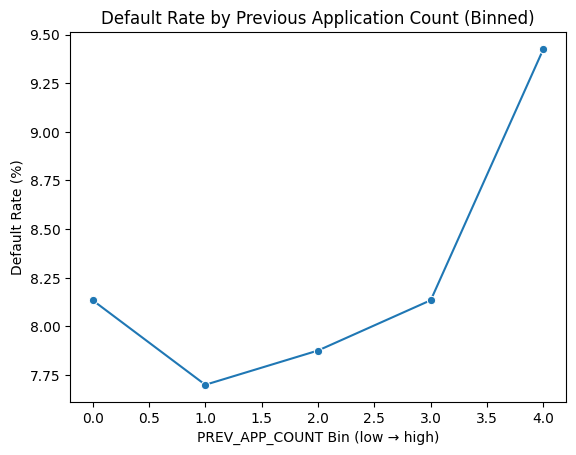

In [ ]:
prev_count_tmp = app_hist[["PREV_APP_COUNT", "TARGET"]].dropna().copy()
prev_count_tmp["PREV_APP_COUNT_BIN"] = pd.qcut(prev_count_tmp["PREV_APP_COUNT"], q=6, duplicates="drop")

prev_count_default = prev_count_tmp.groupby("PREV_APP_COUNT_BIN")["TARGET"].agg(["count", "mean"]).reset_index()
prev_count_default = prev_count_default.rename(columns={"count": "customers", "mean": "default_rate"})
prev_count_default["default_rate"] = prev_count_default["default_rate"] * 100

display(prev_count_default)

sns.lineplot(data=prev_count_default, x=prev_count_default.index, y="default_rate", marker="o")
plt.title("Default Rate by Previous Application Count (Binned)")
plt.xlabel("PREV_APP_COUNT Bin (low → high)")
plt.ylabel("Default Rate (%)")
plt.show()

/tmp/ipykernel_181/3561327253.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prev_refused_default = prev_refused_tmp.groupby("PREV_REFUSED_COUNT_BIN")["TARGET"].agg(["count", "mean"]).reset_index()


,PREV_REFUSED_COUNT_BIN,customers,default_rate
0,"(0.999, 2.0]",69273,9.295108
1,"(2.0, 4.0]",18763,11.650589
2,"(4.0, 68.0]",12258,14.088758


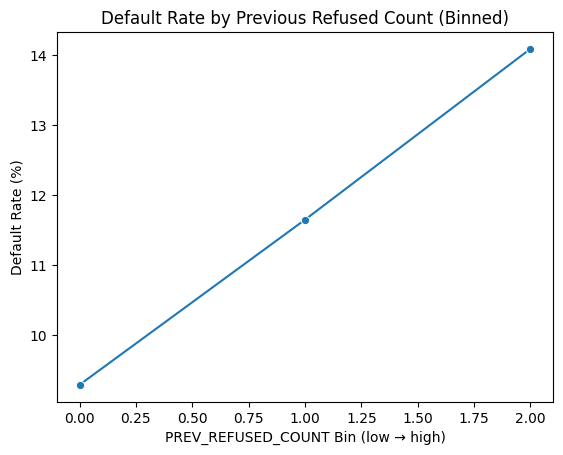

In [ ]:
prev_refused_tmp = app_hist[["PREV_REFUSED_COUNT", "TARGET"]].dropna().copy()
prev_refused_tmp["PREV_REFUSED_COUNT_BIN"] = pd.qcut(prev_refused_tmp["PREV_REFUSED_COUNT"], q=6, duplicates="drop")

prev_refused_default = prev_refused_tmp.groupby("PREV_REFUSED_COUNT_BIN")["TARGET"].agg(["count", "mean"]).reset_index()
prev_refused_default = prev_refused_default.rename(columns={"count": "customers", "mean": "default_rate"})
prev_refused_default["default_rate"] = prev_refused_default["default_rate"] * 100

display(prev_refused_default)

sns.lineplot(data=prev_refused_default, x=prev_refused_default.index, y="default_rate", marker="o")
plt.title("Default Rate by Previous Refused Count (Binned)")
plt.xlabel("PREV_REFUSED_COUNT Bin (low → high)")
plt.ylabel("Default Rate (%)")
plt.show()

### **STEP 7 final summary**



**1. dataset understanding**

application_data = current application-level table

previous_application = historical application-level table

**2. main finding from single factor analysis**

[for detailed explaination of these relationships, please refer to our PPT and GitHub file]

education, income type, occupation type

family status, housing type, car owning condition

financial burden, credit amount, external score


**3. main finding from distribution comparision**

non-default is the majority overall

While the relative size of the default group differs across categories, suggesting that some applicant conditions are associated with higher risk concentration.

Therefore, we add the distribution comparison to complements default-rate analysis by showing both sample size structure and risk composition.

**4. limitations**


no data cleaning

mostly EDA and simple relationships

correlation ≠ causation
